In [6]:
import sys

!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install librosa
!{sys.executable} -m pip install ruptures
!{sys.executable} -m pip install matplotlib

# Imports
import librosa as lb
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

  Using cached contourpy-1.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 6.7 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.1-cp312-cp312-macosx_11_0_arm64.whl (255 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.1 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl (63 kB)
Using cached pillow-11.0.0-cp312-cp312-macosx_11_0_arm64.whl (3.0 MB)
Using cached pyparsing-3.2.0-py3-none-any.whl (106 kB)


In [7]:
# Constants
song_file_path = "/Users/shivamenta/Desktop/training_data copy/dontstopme! (demo).mp3"
FREQUENCY_BUCKETS = [(0, 200), (201, 600), (601, 3000), (3001, 7000), (7001, 22000)]

STFT Change Point Detection

In [8]:
y, sr = lb.load(song_file_path, sr=None)
stft_result = lb.stft(y, n_fft=2048, hop_length=512)
magnitude = np.abs(stft_result)
freqs = lb.fft_frequencies(sr=sr)

freq_bucket_to_signal = [[] for _ in range(len(FREQUENCY_BUCKETS))]
num_time_slices = stft_result.shape[1]

for t in range(num_time_slices):
    for i, (lower, upper) in enumerate(FREQUENCY_BUCKETS):
        freq_indices = np.where((freqs >= lower) & (freqs <= upper))[0]
        bucket_intensity = np.sum(magnitude[freq_indices, t])
        freq_bucket_to_signal[i].append(bucket_intensity)


# Smooth Out Signal
def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


for idx, bucket in enumerate(freq_bucket_to_signal):
    np_arr = np.array(bucket)
    freq_bucket_to_signal[idx] = moving_average(np_arr, 200)

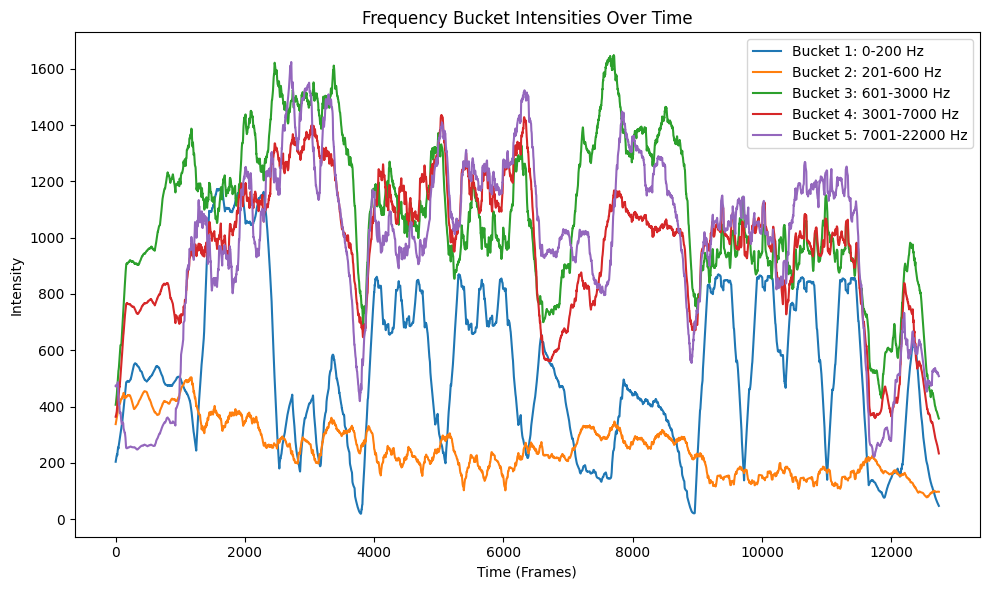

In [9]:
def plot_frequency_buckets(predicted_change_points=[], actual_change_points=[]):
    plt.figure(figsize=(10, 6))

    # Plot each frequency bucket's intensity over time
    for i, bucket in enumerate(freq_bucket_to_signal):
        plt.plot(
            bucket,
            label=f"Bucket {i+1}: {FREQUENCY_BUCKETS[i][0]}-{FREQUENCY_BUCKETS[i][1]} Hz",
        )

    # Label the axes and add a title
    plt.xlabel("Time (Frames)")
    plt.ylabel("Intensity")
    plt.title("Frequency Bucket Intensities Over Time")

    for cp in predicted_change_points:
        plt.axvline(
            x=cp,
            color="red",
            linestyle="--",
            label="Predicted Change Point" if cp == predicted_change_points[0] else "",
        )
    for cp in actual_change_points:
        plt.axvline(
            x=cp,
            color="blue",
            linestyle="--",
            label="Actual Change Point" if cp == predicted_change_points[0] else "",
        )

    # Add a legend to distinguish the different frequency buckets
    plt.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


# Plot the results
plot_frequency_buckets()

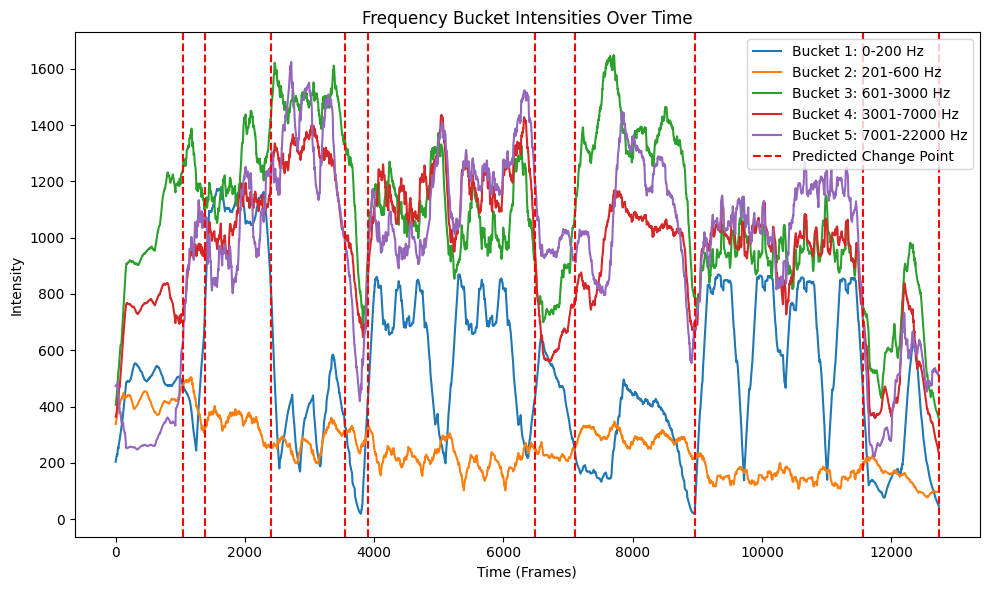

[np.int32(1034), np.int32(1383), np.int32(2403), np.int32(3556), np.int32(3912), np.int32(6490), np.int32(7100), np.int32(8969), np.int32(11557), 12739]


In [10]:
# 200 100000000
mat = np.array(freq_bucket_to_signal).T
model = rpt.KernelCPD(kernel="linear", min_size=157).fit(mat)
estimated_change_points = model.predict(pen=100000000)

plot_frequency_buckets(estimated_change_points, [])
print(estimated_change_points)

Tempogram Change Point Detection